In [49]:
import pandas as pd

# prefix="TOGA_ALL"
# cat ${prefix}_polished_phy_stat/* > ${prefix}_polished_phy_stat.tsv

prefix = "TOGA_ALL"
PATH="/lustre/fs5/jarv_lab/scratch/adenisova/Inno_2025/tmp"

df = pd.read_csv(
    f"{PATH}/{prefix}_polished_phy_stat.tsv",
    sep = "\t",
    names = ["gene","len_seq","number_of_reqs","sp_names"]
)
df.shape

df.sort_values(by = "number_of_reqs", ascending = False)

,gene,len_seq,number_of_reqs,sp_names
9244,RBM22_ENSGALT00000007249.4,1152,229,"Tyrannus_savana,Oxyruncus_cristatus,Pipra_fili..."
2997,ELF2_rna-XM_004940937.3,1782,229,"Tyrannus_savana,Oxyruncus_cristatus,Pipra_fili..."
9552,rna-NM_001277411.1,783,229,"Tyrannus_savana,Oxyruncus_cristatus,Pipra_fili..."
6717,MAP3K8_rna-XM_418581.6,1443,229,"Tyrannus_savana,Oxyruncus_cristatus,Pipra_fili..."
965,BCO2_rna-XM_004948142.3,1710,229,"Tyrannus_savana,Oxyruncus_cristatus,Pipra_fili..."
...,...,...,...,...
11666,rna-XM_025149333.1,243,1,Entomyzon_cyanotis
11376,rna-XM_025145106.1,1266,1,Sylvia_borin
10885,rna-XM_015296521.2,741,1,Nisaetus_nipalensis
3927,ENSGALT00000100062.1,288,1,Grus_nigricollis


In [ ]:
df["number_of_reqs"].describe()

count    15537.000000
mean       178.894252
std         64.919685
min          1.000000
25%        161.000000
50%        212.000000
75%        222.000000
max        229.000000
Name: number_of_reqs, dtype: float64

In [ ]:
df[df["number_of_reqs"] > 161]["gene"].to_csv(
    f"{PATH}/genes_to_filter.txt",
    sep = "\t",
    index = False,
    header = False
)

In [37]:
df.shape

(11009, 4)

In [42]:
from collections import defaultdict

overlapping_sp = {}
sps = defaultdict(int)
for (i, row) in df.iterrows():
    sp_names = set(row["sp_names"].split(","))
    if len(overlapping_sp) == 0:
        overlapping_sp = sp_names
    else:
        overlapping_sp = sp_names & overlapping_sp

    for sp in sp_names:
        sps[sp] += 1

,vals
count,148.000000
mean,9047.141892
std,579.862674
min,5566.000000
25%,8784.500000
50%,9101.500000
75%,9446.750000
max,10113.000000


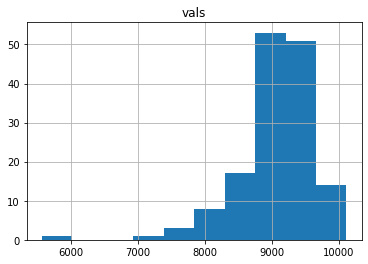

In [43]:
df_sp = pd.DataFrame({"names": sps.keys(), "vals": sps.values()})
df_sp.hist()

df_sp.describe()

In [46]:
sp_to_be_in_every = set(df_sp[df_sp["vals"] > 9446.750000]["names"].unique())
print(len(sp_to_be_in_every))

from collections import defaultdict

overlapping_sp = {}
sps = defaultdict(int)

oks = []
for (i, row) in df.iterrows():
    sp_names = set(row["sp_names"].split(","))
    if len(sp_to_be_in_every - sp_names) == 0:
        oks.append(True)
    else:
        oks.append(False)

df["oks"] = oks

37


In [47]:
df[df["oks"] == True]

,gene,len_seq,number_of_reqs,sp_names,oks
2,A4GNT_rna-XM_426692.5,1164,145,"Smithornis_capensis,Pitta_novaeguineae,Tyrannu...",True
4,AACS_ENSGALT00000004577.6,1794,146,"Smithornis_capensis,Pitta_novaeguineae,Tyrannu...",True
6,AADAT_rna-XM_004940922.3,1263,148,"Smithornis_capensis,Pitta_novaeguineae,Tyrannu...",True
7,AAGAB_ENSGALT00000104070.1,765,147,"Smithornis_capensis,Pitta_novaeguineae,Tyrannu...",True
8,AAK1_rna-XM_015297334.2,3357,146,"Smithornis_capensis,Pitta_novaeguineae,Tyrannu...",True
...,...,...,...,...,...
10999,ZNF438_rna-XM_025148331.1,2574,143,"Smithornis_capensis,Pitta_novaeguineae,Tyrannu...",True
11004,ZNF507_rna-XM_004944220.3,2946,143,"Smithornis_capensis,Pitta_novaeguineae,Tyrannu...",True
11005,ZNF511_ENSGALT00000005587.8,654,143,"Smithornis_capensis,Pitta_novaeguineae,Tyrannu...",True
11006,ZNF512B_rna-XM_015296423.2,2322,146,"Smithornis_capensis,Pitta_novaeguineae,Tyrannu...",True
